In [1]:
from pybaseball import statcast_pitcher
from pybaseball import playerid_lookup
import pandas as pd

In [2]:
playerid_lookup('chapman', 'aroldis')

Gathering player lookup table. This may take a moment.


,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,chapman,aroldis,547973,chapa001,chapmar01,10233,2010.0,2025.0


In [3]:
chapman = statcast_pitcher('2020-01-01', '2024-12-31', player_id=547973)
chapman.shape

Gathering Player Data


(4539, 118)

In [4]:
chapman.columns.tolist()

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [9]:
cols = [
    'game_year',
    'pitch_type',
    'release_speed',
    'release_spin_rate',
    'release_pos_x',
    'release_pos_z',
    'events'
]

chapman_clean = chapman[cols].copy()
chapman_clean.shape

(4539, 7)

In [10]:
chapman_clean.head()

,game_year,pitch_type,release_speed,release_spin_rate,release_pos_x,release_pos_z,events
0,2024,FF,98.9,2472.0,0.30,6.26,field_out
1,2024,FF,98.9,2487.0,0.25,6.37,NaN
2,2024,SL,91.0,2288.0,0.64,6.25,NaN
3,2024,SI,100.6,2394.0,0.29,6.37,strikeout
4,2024,FF,99.9,2526.0,0.35,6.26,NaN


In [11]:
chapman_clean.isnull().sum()

game_year               0
pitch_type            107
release_speed         105
release_spin_rate     113
release_pos_x         105
release_pos_z         105
events               3432
dtype: int64

In [12]:
chapman_clean = chapman_clean.dropna(subset=['pitch_type', 'release_speed'])
chapman_clean.shape

(4432, 7)

In [13]:
chapman_clean['game_year'].value_counts().sort_index()

game_year
2020     268
2021    1091
2022     731
2023    1136
2024    1206
Name: count, dtype: int64

In [15]:
pitch_mix = chapman_clean.groupby(['game_year', 'pitch_type']).size().unstack(fill_value=0)
pitch_mix_pct = pitch_mix.div(pitch_mix.sum(axis=1), axis=0) * 100
print(pitch_mix_pct.round(1))

pitch_type    FF    FS    SI    SL
game_year                         
2020        73.5   2.6   5.6  18.3
2021        56.4  11.0   5.4  27.2
2022        55.1  14.5   5.2  25.2
2023        49.1   7.0  16.3  27.6
2024        33.0  13.1  27.7  26.2


In [17]:
print(pitch_mix_pct.round(1).to_string())

pitch_type    FF    FS    SI    SL
game_year                         
2020        73.5   2.6   5.6  18.3
2021        56.4  11.0   5.4  27.2
2022        55.1  14.5   5.2  25.2
2023        49.1   7.0  16.3  27.6
2024        33.0  13.1  27.7  26.2


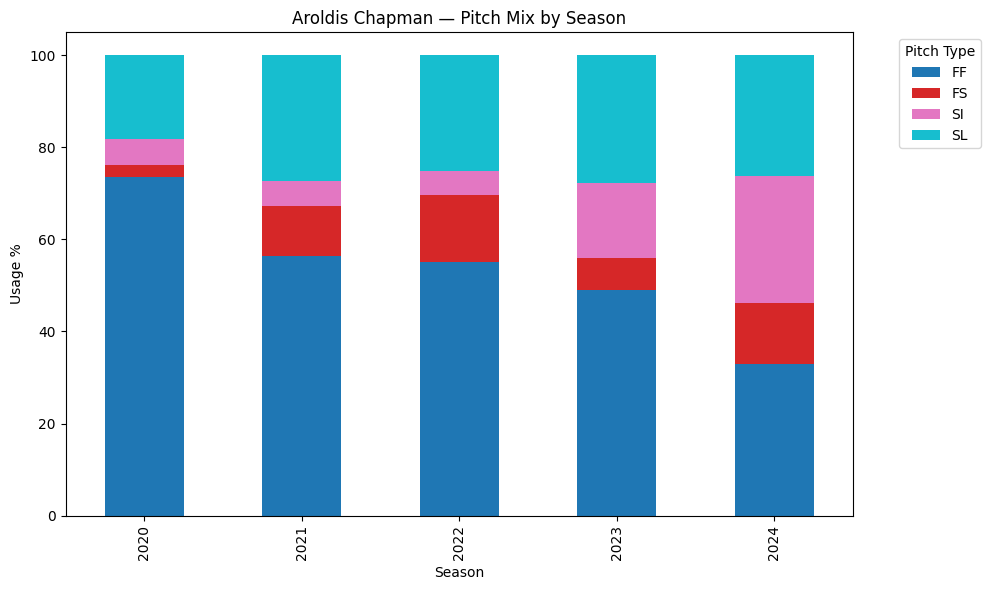

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = pitch_mix_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10'
)

ax.set_title("Aroldis Chapman — Pitch Mix by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Usage %")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
velocity = chapman_clean.groupby(['game_year', 'pitch_type'])['release_speed'].mean().unstack()
print(velocity.round(1))

pitch_type    FF    FS     SI    SL
game_year                          
2020        97.9  90.4  100.2  85.3
2021        98.2  88.4  100.6  85.0
2022        97.4  88.0  100.1  85.6
2023        99.0  90.5  101.1  88.1
2024        97.7  91.0   99.7  86.9


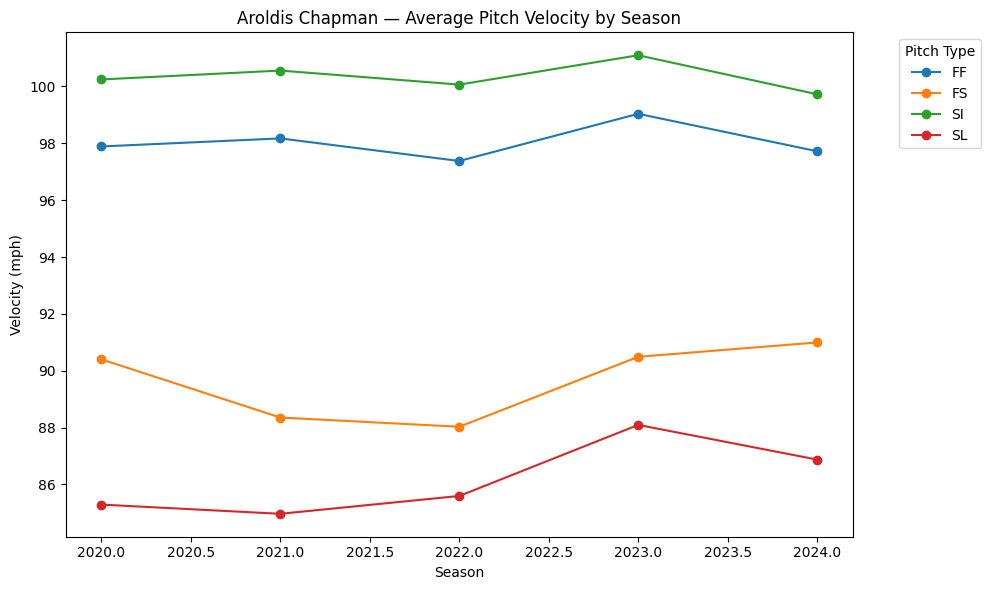

In [20]:
ax = velocity.plot(
    kind='line',
    figsize=(10, 6),
    marker='o'
)

ax.set_title("Aroldis Chapman — Average Pitch Velocity by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Velocity (mph)")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
spin = chapman_clean.groupby(['game_year', 'pitch_type'])['release_spin_rate'].mean().unstack()
print(spin.round(1))

pitch_type      FF      FS      SI      SL
game_year                                 
2020        2434.7  1335.9  2526.3  2348.6
2021        2374.3   789.1  2393.7  2271.3
2022        2352.7   832.7  2430.8  2276.2
2023        2409.0  1182.5  2395.0  2312.4
2024        2360.8  1237.0  2360.7  2243.7


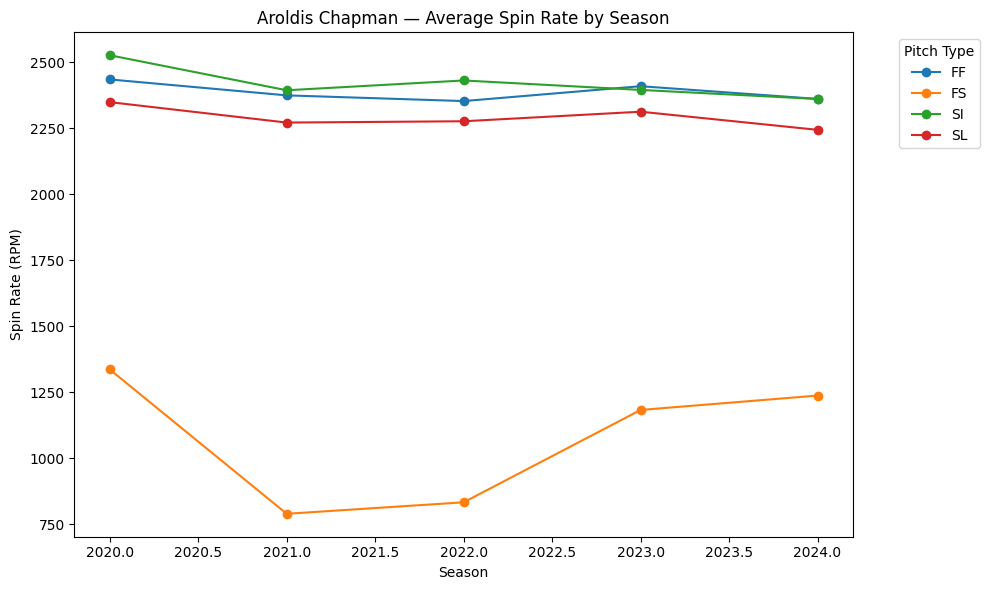

In [22]:
ax = spin.plot(
    kind='line',
    figsize=(10, 6),
    marker='o'
)

ax.set_title("Aroldis Chapman — Average Spin Rate by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Spin Rate (RPM)")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()